<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; 客户成功分析</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">客户流失根本原因分析</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">PROC FISHBONE 因果图，用于中型市场 B2B SaaS 客户留存审查</div>
</div>

## 执行摘要

本分析将中型市场 B2B SaaS 客户流失升高的根本原因驱动因素，整理为一份结构化的因果（石川/鱼骨）图。中型市场细分领域的年化流失率约为18%，而目标值为8%。二十项根因发现——来自退出调研、客户成功访谈和群组归因分析——被归入六个原因类别，并通过 `PROC FISHBONE` 渲染为一张27节点的图（一个结果、六根类别主骨、二十个子原因）。

配套的 `PROC MEANS` 明细显示了可归因流失集中于哪些方面。**产品（Product）** 拥有最多的发现（5项原因，共48.1个影响分），其次是**定价（Pricing）**（4项原因，共42.3）和**支持（Support）**（4项原因，共40.2）。若按*每项原因*的平均影响衡量，**竞争（Competition）** 是最严重的类别（均值11.8），而单项影响最高的发现是**定价**类别中"续约涨价未提前通知"这一项（14.2）。`PROC SGPLOT` 帕累托视图对每一项具体原因按影响排名，便于管理层看清应优先处理哪些主骨。该成果供客户成功团队的季度留存审查使用。

## 数据来源

| 来源 | 描述 | 记录数 |
|--------|-------------|--------|
| WORK.CHURN_RCA | 从退出调研分析和客户成功团队复盘中汇总的客户流失根因发现；每行为一项原因，包含其类别、支持性证据以及估计的流失影响占比 | 20 |

---

In [1]:
/* --------------------------------------------------------
   客户流失根本原因发现（RCA）
   SaaS平台，B2B中型市场细分领域。
   每行：原因类别、具体原因、支持性子原因/证据说明，
   以及可归因流失的估计占比
   （来自退出调研与群组归因分析）。
   -------------------------------------------------------- */
数据 work.churn_rca;
    长度 category $20 cause $100 subcause $150;
    INFILE DATALINES dlm='|' dsd truncover;
    输入 category :$20. cause :$100. subcause :$150. churn_impact_pct;
    DATALINES;
产品|相较于企业级竞争对手核心功能存在差距|34%的退出调研提及批量导出与API速率限制|12.4
产品|报表能力有限|标准版没有自定义仪表盘构建器|9.8
产品|移动端功能落后于网页端|3项关键流程仅限网页端用户无法在移动端完成|8.2
产品|界面频繁变更且不预先通知|重度用户因季度改版而受到干扰|7.6
产品|集成市场存在缺口|缺少Salesforce和HubSpot原生连接器|10.1
定价|续约涨价未提前通知|月度经常性收入上涨18%且仅提前30天通知|14.2
定价|按坐席计费模式惩罚团队增长|团队从10人增至20人时成本翻倍|11.3
定价|首年折扣不可续期|首次续约时价格冲击明显|9.7
定价|无多年期合同优惠|年付价格与按月付费完全相同|7.1
支持|首次响应时间超过24小时|服务等级基准为4小时|10.8
支持|周末支持质量差|离岸支持团队缺乏产品知识|9.3
支持|企业版以下无专属客户成功经理|中型市场账户没有指定联系人|11.5
支持|升级路径对客户不清晰|38%的流失账户提及对升级流程感到困惑|8.6
入职|价值实现周期超过90天|售前未充分披露实施复杂度|12.9
入职|自助文档已过时|上次更新为11个月前|8.1
入职|新功能缺少应用内引导|6个月时功能采用率低于30%|9.4
竞争|竞争对手价格低30%|三个主要账户提及具体竞争对手|13.1
竞争|竞争对手提供无限坐席定价|消除了团队增长时的按坐席惩罚|10.6
关系|高管发起人离职后未妥善处理|拥护者离职后无重新建立联系的机制|11.7
关系|季度业务回顾频率降至每年一次|18个月前客户成功团队资源被削减|9.2
;
运行;


NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   基线：按RCA类别划分的流失影响集中度。
   总和显示可归因流失集中在何处；最大值标出
   每个类别中最严重的单项原因。
   -------------------------------------------------------- */
过程 均值 数据=work.churn_rca n sum mean MAX maxdec=1;
    分类 category;
    变量 churn_impact_pct;
    标签 category="原因类别" churn_impact_pct="流失影响占比(%)";
    标题 "客户流失RCA：按类别划分的影响占比";
运行;

                                                   客户流失RCA：按类别划分的影响占比                                                   

                                                  The MEANS Procedure

                               Analysis Variable : churn_impact_pct 流失影响占比(%)

        原因类别                  N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------
        产品                        5           48.1            9.6           12.4
        入职                        3           30.4           10.1           12.9
        关系                        2           20.9           10.4           11.7
        定价                        4           42.3           10.6           14.2
        支持                        4           40.2           10.1           11.5
        竞争                        2           23.7           11.8           13.1
        ------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                   客户流失RCA：按类别划分的影响占比                                                   




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


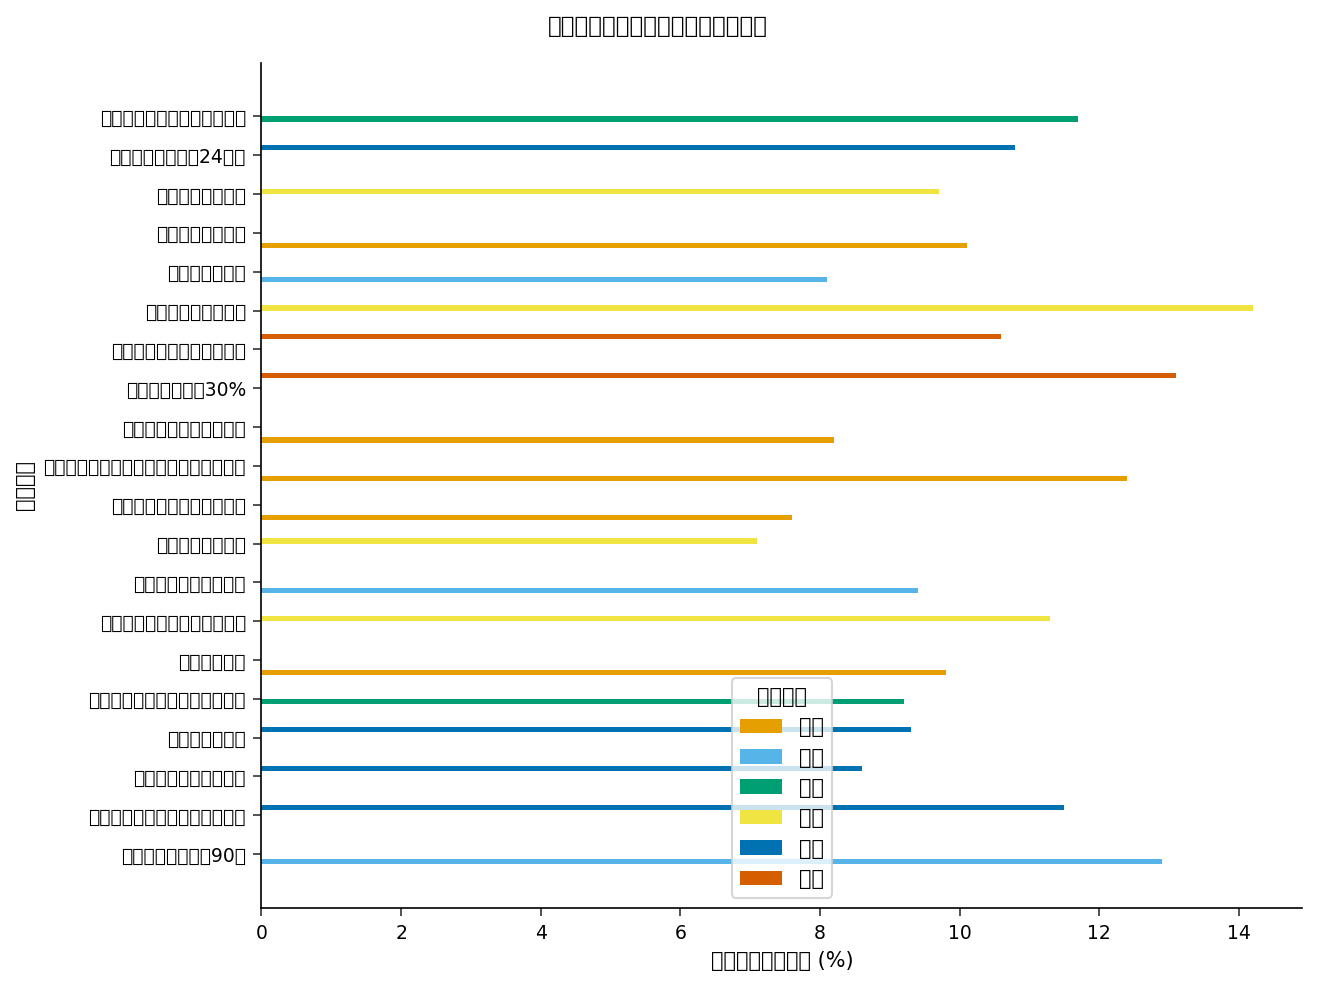

In [3]:
/* --------------------------------------------------------
   帕累托视图：按估计流失影响对各项根因排序，
   并按类别着色。此图与鱼骨图互补，用于量化
   哪些主骨最为重要。
   -------------------------------------------------------- */
过程 排序 数据=work.churn_rca;
    按照 DESCENDING churn_impact_pct;
运行;

过程 SGPLOT 数据=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS 标签="估计流失影响占比 (%)";
    YAXIS 标签="根本原因" discreteorder=data;
    keylegend / title="原因类别" position=bottom;
    标题 "按估计影响排序的客户流失根本原因";
运行;

---

### 因果（石川/鱼骨）图

`PROC FISHBONE` 直接基于 `WORK.CHURN_RCA` 构建该图：每个不同的 `category`（类别）成为中心主干上的一根主骨，各项具体的 `cause`（原因）发现则作为子原因悬挂在其类别主骨下。该过程会在下方打印完整的因果结构——头部的结果、六根类别主骨，以及归入各自主骨下的每一项子原因——并将匹配的鱼骨图形写入磁盘。上方的排序帕累托图是配套视图，用于量化这些主骨中哪些承载了最多的可归因流失。

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE：客户流失因果图。
   该图直接基于 WORK.CHURN_RCA 驱动，因此六个原因类别
   及其具体原因，正是上文分析的发现结果。CATEGORY
   构成主骨；CAUSE 作为子原因悬挂在各主骨之下。
   -------------------------------------------------------- */
过程 fishbone 数据=work.churn_rca;
    cause category / subcause=cause;
    effect "客户流失率升高（年化18% 对比目标8%）";
    标题 "客户流失根本原因分析 - 中型市场细分领域";
    footnote "数据来源：退出调研、客户成功团队访谈、群组归因分析";
    标签 category="原因类别" cause="具体原因";
运行;

                                                   客户流失RCA：按类别划分的影响占比                                                   


                    客户流失根本原因分析 - 中型市场细分领域
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] 客户流失率升高（年化18% 对比目标8%）
    [CAUSE] 定价 (top)
      [SUB] 续约涨价未提前通知
      [SUB] 按坐席计费模式惩罚团队增长
      [SUB] 首年折扣不可续期
      [SUB] 无多年期合同优惠
    [CAUSE] 竞争 (top)
      [SUB] 竞争对手价格低30%
      [SUB] 竞争对手提供无限坐席定价
    [CAUSE] 入职 (top)
      [SUB] 价值实现周期超过90天
      [SUB] 新功能缺少应用内引导
      [SUB] 自助文档已过时
    [CAUSE] 产品 (bottom)
      [SUB] 相较于企业级竞争对手核心功能存在差距
      [SUB] 集成市场存在缺口
      [SUB] 报表能力有限
      [SUB] 移动端功能落后于网页端
      [SUB] 界面频繁变更且不预先通知
    [CAUSE] 关系 (bottom)
      [SUB] 高管发起人离职后未妥善处理
      [SUB] 季度业务回顾频率降至每年一次
    [CAUSE] 支持 (bottom)
      [SUB] 企业版以下无专属客户成功经理
      [SUB] 首次响应时间超过24小时
      [SUB] 周末支持质量差
      [SUB] 升级路径对客户不清晰

  Total nodes: 27

  数据来源：退出调研、客户成功团队访谈、群组归因分析




NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### 结果解读

因果结构以及各类别的 `PROC MEANS` 数据，为管理层指出了少数几项高杠杆举措。两项单一原因中影响最高的发现——**定价**类别中未提前通知的续约涨价（14.2）和**竞争**类别中"竞争对手以低30%价格提供同等能力"这一发现（13.1）——都属于商业性而非产品性问题，说明定价透明度和竞争定位是当前最紧迫的近期杠杆点。**入职（Onboarding）** 类别中价值实现周期超过90天（12.9）是最大的服务侧发现，且与售前预期设定直接相关。

从数量上看，**产品** 在图中占主导地位（20项发现中的5项，共48.1个影响分），但其单项发现的影响相对较小（均值9.6），低于**竞争**（均值11.8）或**定价**（均值10.6）——这提醒我们，产品缺口清单虽长，却不一定自动成为首要优先事项。**关系（Relationship）** 主骨（高管发起人离职未妥善处理，以及季度业务回顾频率降至每年一次，合计影响20.9）代表的是客户成功团队可在本季度内实施、且无需产品或定价投入的流程性变更，是实现可衡量留存改善的最快路径。帕累托图中的完整排序列表，让管理团队能够按估计影响而非类别规模来安排干预措施的优先级。

---

In [5]:
/* --------------------------------------------------------
   导出客户流失RCA发现，供战略复盘展示材料使用
   -------------------------------------------------------- */
过程 EXPORT 数据=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 保密文件
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>